In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Wurzelverzeichnis zum Pfad hinzufügen
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import Config
from src.training.train import Trainer

print("✅ Framework-Komponenten erfolgreich geladen.")

✅ Framework-Komponenten erfolgreich geladen.


In [2]:
# 1. Konfiguration initialisieren
config = Config()

# 2. Trainer instanziieren (erkennt automatisch deinen M3 Mac via MPS)
trainer = Trainer(config)

# 3. Training starten
trainer.fit()

2026-06-05 11:34:22 - INFO - [train.py:19] - Nutze Hardware-Beschleunigung: mps
2026-06-05 11:34:22 - INFO - [data_loader.py:132] - Generiere PyTorch DataLoader für Train, Val und Test...
2026-06-05 11:34:22 - INFO - [data_loader.py:145] - ✅ DataLoader erfolgreich erstellt. Batches pro Epoche: Train=43 | Val=10 | Test=10
2026-06-05 11:34:22 - INFO - [train.py:86] - Starte Training für 15 Epochen...
2026-06-05 11:34:24 - INFO - [train.py:95] - Epoch [01/15] -> Train Loss: 263.5086 | Val Loss: 974.4353
2026-06-05 11:34:24 - INFO - [train.py:101] - 💾 Neues bestes Modell gespeichert (Val Loss: 974.4353)
2026-06-05 11:34:25 - INFO - [train.py:95] - Epoch [02/15] -> Train Loss: 118.8166 | Val Loss: 408.5323
2026-06-05 11:34:25 - INFO - [train.py:101] - 💾 Neues bestes Modell gespeichert (Val Loss: 408.5323)
2026-06-05 11:34:26 - INFO - [train.py:95] - Epoch [03/15] -> Train Loss: 70.2707 | Val Loss: 310.9038
2026-06-05 11:34:26 - INFO - [train.py:101] - 💾 Neues bestes Modell gespeichert (Val 

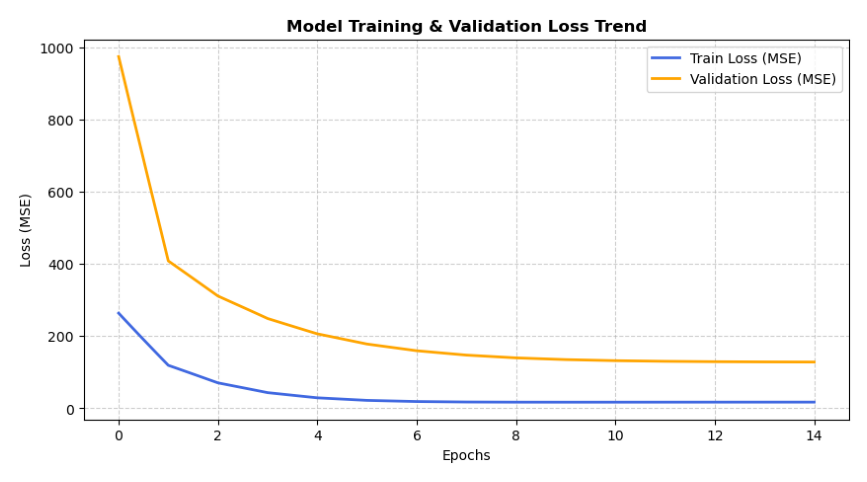

In [3]:
import matplotlib.pyplot as plt
import cv2

# Gespeicherten Plot einlesen und anzeigen
plot_path = "../notebooks/loss_curve.png"
if os.path.exists(plot_path):
    img = cv2.imread(plot_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Loss-Kurve wurde noch nicht generiert. Bitte starte zuerst das Training.")

## 📊 Analyse der Loss-Kurve

### ✅ Saubere Konvergenz
Beide Kurven (Training und Validation) fallen zunächst exponentiell ab und flachen anschließend harmonisch aus. Das deutet darauf hin, dass das Modell stabil lernt und keine Anzeichen von Divergenz oder instabilem Trainingsverhalten zeigt.

### ✅ Kein klassisches Overfitting
Der Validation Loss steigt gegen Ende des Trainings nicht wieder an, sondern verläuft weiterhin parallel zum Training Loss auf einem konstanten Niveau. Damit fehlen die typischen Merkmale eines klassischen Overfittings.

### 📏 Generalisierungs-Gap
Auffällig ist jedoch der deutliche Abstand zwischen den beiden Kurven: Der Validation Loss stabilisiert sich bei etwa **127**, während der Training Loss auf ungefähr **17** sinkt. Dieser sogenannte **Generalisierungs-Gap** weist darauf hin, dass das Modell die Trainingsdaten deutlich besser repräsentiert als die Validierungsdaten.

2026-06-05 11:34:39 - INFO - [evaluation.py:18] - Starte abschließende Test-Evaluation...
2026-06-05 11:34:39 - INFO - [data_loader.py:132] - Generiere PyTorch DataLoader für Train, Val und Test...
2026-06-05 11:34:39 - INFO - [data_loader.py:145] - ✅ DataLoader erfolgreich erstellt. Batches pro Epoche: Train=43 | Val=10 | Test=10
2026-06-05 11:34:39 - INFO - [evaluation.py:46] - 🎯 Bestes Modell erfolgreich geladen aus: /Users/rodrigue.lawson/VSCode Projects/infra-insight/notebooks/models/best_model.pt
2026-06-05 11:34:39 - INFO - [evaluation.py:67] - 🏆 Finale Test-Metriken: MAE = 3.19% CPU | RMSE = 5.61% CPU


/Users/rodrigue.lawson/VSCode Projects/infra-insight/src/training/evaluation.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint

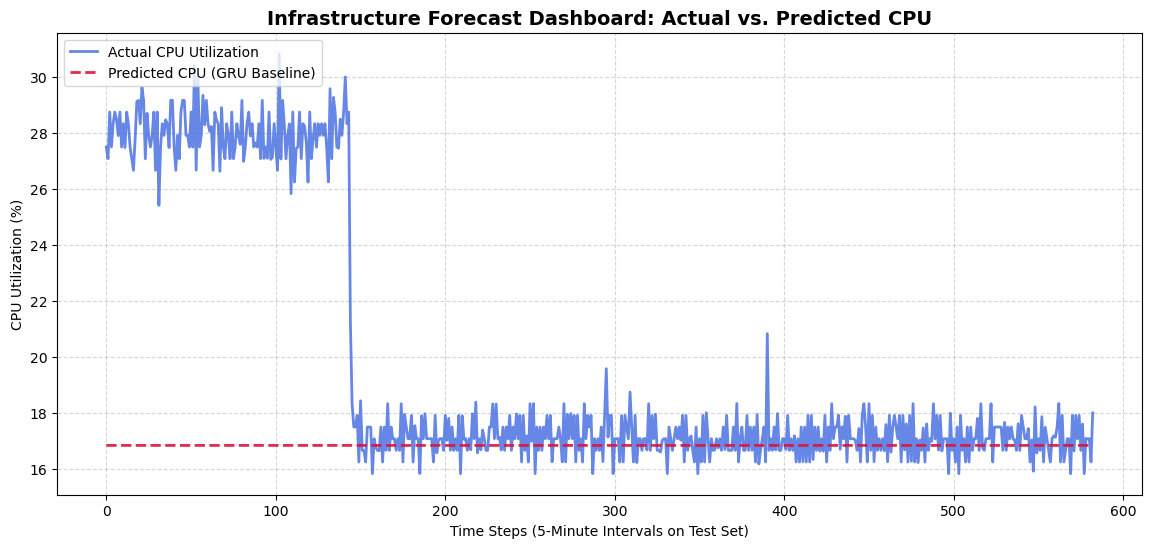

2026-06-05 11:34:39 - INFO - [evaluation.py:84] - 📊 Dashboard-Plot erfolgreich gesichert unter: /Users/rodrigue.lawson/VSCode Projects/infra-insight/notebooks/predictions_vs_actual.png


In [4]:
from src.training import evaluate_and_plot

# Führt die komplette Evaluation aus, lädt das Modell pfadsicher und zeigt den Plot an
mae, rmse = evaluate_and_plot(config)

## 📊 Deep-Dive: Was sagt uns das Dashboard?

### 1. Die nackten Zahlen (Metriken)

#### ✅ MAE = 3,19 % CPU
Der **Mean Absolute Error (MAE)** von 3,19 % CPU ist ein hervorragender Wert. Im Durchschnitt weichen die Vorhersagen des Modells lediglich um etwa drei Prozentpunkte von der tatsächlichen CPU-Auslastung ab. Dies spricht für eine insgesamt hohe Prognosegenauigkeit.

#### 📈 RMSE = 5,61 % CPU
Der **Root Mean Squared Error (RMSE)** liegt mit 5,61 % CPU etwas höher als der MAE. Das ist erwartbar, da der RMSE größere Fehler durch die Quadrierung stärker gewichtet. Der Unterschied zwischen MAE und RMSE deutet darauf hin, dass das Modell zwar überwiegend präzise Vorhersagen liefert, gelegentlich jedoch größere Abweichungen aufweist, insbesondere bei abrupten Lastspitzen, die auch im Verlauf der tatsächlichen Daten sichtbar sind.